# Mapping von Institutionen

In [1]:
from google.cloud import bigquery
import pandas as pd
from typing import Union
import re
import json
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [2]:
sns.set_style('whitegrid')
plt.rc('font', family='Arial')
plt.rc('font', size=9) 
plt.rc('axes', titlesize=9) 
plt.rc('axes', labelsize=9) 
plt.rc('xtick', labelsize=9) 
plt.rc('ytick', labelsize=9) 
plt.rc('legend', fontsize=9)

In [3]:
client = bigquery.Client(project='subugoe-collaborative')

In [4]:
kb = client.query(f"""
                    SELECT 
                        CASE 
                            -- WHEN kb_inst.ror = 'https://ror.org/021ft0n22' THEN 'Universitätsmedizin Göttingen' # in der KB-Kodierung als GAU kodiert
                            WHEN kb_inst.ror = 'https://ror.org/02w2y2t16' THEN 'Leuphana Universität Lüneburg'
                            WHEN kb_inst.ror = 'https://ror.org/033n9gh91' THEN 'Carl von Ossietzky Universität Oldenburg'
                            WHEN kb_inst.ror = 'https://ror.org/02vvvm705' THEN 'Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth'
                            WHEN kb_inst.ror = 'https://ror.org/01bc76c69' THEN 'Hochschule Emden/Leer'
                            WHEN kb_inst.ror = 'https://ror.org/0304hq317' THEN 'Gottfried Wilhelm Leibniz Universität Hannover'
                            WHEN kb_inst.ror = 'https://ror.org/00x67m532' THEN 'Hochschule für Musik, Theater und Medien Hannover'
                            WHEN kb_inst.ror = 'https://ror.org/03m2kj587' THEN 'Hochschule Hannover'
                            WHEN kb_inst.ror = 'https://ror.org/015qjqf64' THEN 'Stiftung Tierärztliche Hochschule Hannover'
                            WHEN kb_inst.ror = 'https://ror.org/00f2yqf98' THEN 'Medizinische Hochschule Hannover (MHH)'
                            WHEN kb_inst.ror = 'https://ror.org/00f5q5839' THEN 'HAWK Hochschule für angewandte Wissenschaft und Kunst'
                            WHEN kb_inst.ror = 'https://ror.org/02f9det96' THEN 'Stiftung Universität Hildesheim'
                            WHEN kb_inst.ror = 'https://ror.org/01y9bpm73' THEN 'Georg-August-Universität Göttingen'
                            WHEN kb_inst.ror = 'https://ror.org/010nsgg66' THEN 'Technische Universität Braunschweig'
                            WHEN kb_inst.ror = 'https://ror.org/03aft2f80' THEN 'Hochschule für Bildende Künste Braunschweig'
                            WHEN kb_inst.ror = 'https://ror.org/01bk10867' THEN 'Ostfalia Hochschule für angewandte Wissenschaften'
                            WHEN kb_inst.ror = 'https://ror.org/04qb8nc58' THEN 'Technische Universität Clausthal'
                            WHEN kb_inst.ror = 'https://ror.org/04qmmjx98' THEN 'Universität Osnabrück'
                            WHEN kb_inst.ror = 'https://ror.org/059vymd37' THEN 'Hochschule Osnabrück'
                            WHEN kb_inst.ror = 'https://ror.org/045y6d111' THEN 'Universität Vechta'
                            -- Ergänzung von Suborganisationen (Oldenburg)
                            WHEN inst_id = 445 THEN 'Carl von Ossietzky Universität Oldenburg'
                            WHEN inst_id = 6612 THEN 'Carl von Ossietzky Universität Oldenburg'
                            WHEN inst_id = 316 THEN 'Carl von Ossietzky Universität Oldenburg'
                            WHEN inst_id = 315 THEN 'Carl von Ossietzky Universität Oldenburg'
                            WHEN inst_id = 5488 THEN 'Carl von Ossietzky Universität Oldenburg'
                            WHEN inst_id = 4564 THEN 'Carl von Ossietzky Universität Oldenburg'
                            ELSE ''
                        END AS parent_name,
                        CASE 
                            -- Ergänzung von Suborganisationen (Oldenburg)
                            WHEN inst_id = 445 THEN 'Universitätsmedizin Oldenburg'
                            WHEN inst_id = 6612 THEN 'Universitätsmedizin Oldenburg'
                            WHEN inst_id = 316 THEN 'Universitätsmedizin Oldenburg'
                            WHEN inst_id = 315 THEN 'Universitätsmedizin Oldenburg'
                            WHEN inst_id = 5488 THEN 'Helmholtz-Institut für Funktionelle Marine Biodiversität'
                            WHEN inst_id = 4564 THEN 'Institute for Science Networking Oldenburg GmbH'
                            ELSE 'not assigned'
                        END AS fak_name,
                        inst.address_full AS raw_affiliation_string,
                        doi
                    FROM `subugoe-collaborative.resources.kb_a_addr_inst_202603` AS inst
                    JOIN `subugoe-collaborative.resources.add_institution_lookup_kb_suppl_202603` AS kb_inst
                      ON inst.inst_id_top = kb_inst.inst_id
                    JOIN `subugoe-collaborative.openalex_walden.works` AS oal
                        ON CONCAT('https://openalex.org/', inst.item_id) = oal.id
                    WHERE oal.type IN ('article', 'review') 
                        AND primary_location.source.type='journal'
                        AND is_paratext=FALSE 
                        AND is_retracted=FALSE 
                        AND is_xpac=FALSE
                        AND publication_year BETWEEN 2020 AND 2024
                        AND (kb_inst.ror IN (
                            'https://ror.org/021ft0n22', -- Universitätsmedizin Göttingen
                            'https://ror.org/02w2y2t16', -- Leuphana Universität Lüneburg
                            'https://ror.org/033n9gh91', -- Carl von Ossietzky Universität Oldenburg
                            'https://ror.org/02vvvm705', -- Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth
                            'https://ror.org/01bc76c69', -- Hochschule Emden/Leer
                            'https://ror.org/0304hq317', -- Gottfried Wilhelm Leibniz Universität Hannover
                            'https://ror.org/00x67m532', -- Hochschule für Musik, Theater und Medien Hannover
                            'https://ror.org/03m2kj587', -- Hochschule Hannover
                            'https://ror.org/015qjqf64', -- Stiftung Tierärztliche Hochschule Hannover
                            'https://ror.org/00f2yqf98', -- Medizinische Hochschule Hannover (MHH)
                            'https://ror.org/00f5q5839', -- HAWK Hochschule für angewandte Wissenschaft und Kunst
                            'https://ror.org/02f9det96', -- Stiftung Universität Hildesheim
                            'https://ror.org/01y9bpm73', -- Georg-August-Universität Göttingen
                            'https://ror.org/010nsgg66', -- Technische Universität Braunschweig
                            'https://ror.org/03aft2f80', -- Hochschule für Bildende Künste Braunschweig
                            'https://ror.org/01bk10867', -- Ostfalia Hochschule für angewandte Wissenschaften
                            'https://ror.org/04qb8nc58', -- Technische Universität Clausthal
                            'https://ror.org/04qmmjx98', -- Universität Osnabrück
                            'https://ror.org/059vymd37', -- Hochschule Osnabrück
                            'https://ror.org/045y6d111' -- Universität Vechta
                        ) OR kb_inst.inst_id IN (
                             -- Ergänzung von Suborganisationen (Oldenburg)
                             445, -- 'Evangelisches Krankenhaus Oldenburg'
                             6612, -- 'UMO - Universitätsmedizin Oldenburg'
                             316, -- 'Klinikum Oldenburg gGmbH'
                             315, -- 'Pius-Hospital Oldenburg'
                             5488, -- 'Helmholtz-Institut für Funktionelle Marine Biodiversität an der Universität Oldenburg (HIFMB)'
                             4564 -- Institute for Science Networking Oldenburg GmbH
                            )
                        )
                    ORDER BY fak_name
                    """).to_dataframe()

In [5]:
#kb.replace({'Universitätsmedizin Oldenburg': 'Fakultät VI - Medizin und Gesundheitswissenschaften'}, inplace=True)

In [6]:
kb.head()

,parent_name,fak_name,raw_affiliation_string,doi
0,Carl von Ossietzky Universität Oldenburg,Helmholtz-Institut für Funktionelle Marine Bio...,4Helmholtz Institute for Functional Marine Bio...,10.1525/elementa.2021.00117
1,Carl von Ossietzky Universität Oldenburg,Helmholtz-Institut für Funktionelle Marine Bio...,Helmholtz Institute for Functional Marine Biod...,10.1038/s41598-022-17999-y
2,Carl von Ossietzky Universität Oldenburg,Helmholtz-Institut für Funktionelle Marine Bio...,Helmholtz Institute for Functional Marine Biod...,10.3389/fmars.2023.1159762
3,Carl von Ossietzky Universität Oldenburg,Helmholtz-Institut für Funktionelle Marine Bio...,Helmholtz Institute for Functional Marine Biod...,10.3389/fmars.2023.1128322
4,Carl von Ossietzky Universität Oldenburg,Helmholtz-Institut für Funktionelle Marine Bio...,Helmholtz Institute for Functional Marine Biod...,10.5194/esd-13-1677-2022


In [7]:
with open('institution_mapping/mapping_tables_fak/clausthal.json', 'r') as file:
    CLAUSTHAL_MAPPING = json.load(file)

In [8]:
with open('institution_mapping/mapping_tables_fak/emden.json', 'r') as file:
    EMDEN_MAPPING = json.load(file)

In [9]:
with open('institution_mapping/mapping_tables_fak/gau.json', 'r') as file:
    GAU_MAPPING = json.load(file)

In [10]:
with open('institution_mapping/mapping_tables_fak/hawk.json', 'r') as file:
    HAWK_MAPPING = json.load(file)

In [11]:
with open('institution_mapping/mapping_tables_fak/hbk.json', 'r') as file:
    HBK_MAPPING = json.load(file)

In [12]:
with open('institution_mapping/mapping_tables_fak/hildesheim.json', 'r') as file:
    HILDESHEIM_MAPPING = json.load(file)

In [13]:
with open('institution_mapping/mapping_tables_fak/hmtmh.json', 'r') as file:
    HMTMH_MAPPING = json.load(file)

In [14]:
with open('institution_mapping/mapping_tables_fak/hsh.json', 'r') as file:
    HSH_MAPPING = json.load(file)

In [15]:
with open('institution_mapping/mapping_tables_fak/hsosnabrueck.json', 'r') as file:
    HSOSNABRÜCK_MAPPING = json.load(file)

In [16]:
with open('institution_mapping/mapping_tables_fak/jade.json', 'r') as file:
    JADE_MAPPING = json.load(file)

In [17]:
with open('institution_mapping/mapping_tables_fak/leibniz.json', 'r') as file:
    LEIBNIZ_MAPPING = json.load(file)

In [18]:
with open('institution_mapping/mapping_tables_fak/leuphana.json', 'r') as file:
    LEUPHANA_MAPPING = json.load(file)

In [19]:
with open('institution_mapping/mapping_tables_fak/mhh.json', 'r') as file:
    MHH_MAPPING = json.load(file)

In [20]:
with open('institution_mapping/mapping_tables_fak/oldenburg.json', 'r') as file:
    OLDENBURG_MAPPING = json.load(file)

In [21]:
with open('institution_mapping/mapping_tables_fak/ostfalia.json', 'r') as file:
    OSTFALIA_MAPPING = json.load(file)

In [22]:
with open('institution_mapping/mapping_tables_fak/tiho.json', 'r') as file:
    TIHO_MAPPING = json.load(file)

In [23]:
with open('institution_mapping/mapping_tables_fak/tubraunschweig.json', 'r') as file:
    TUBRAUNSCHWEIG_MAPPING = json.load(file)

In [24]:
with open('institution_mapping/mapping_tables_fak/uosnabrueck.json', 'r') as file:
    UOSNABRÜCK_MAPPING = json.load(file)

In [25]:
with open('institution_mapping/mapping_tables_fak/vechta.json', 'r') as file:
    VECHTA_MAPPING = json.load(file)

In [26]:
MAPPING_DICT_FAK = {
    'Technische Universität Clausthal': CLAUSTHAL_MAPPING,
    'Hochschule Emden/Leer': EMDEN_MAPPING,
    'Georg-August-Universität Göttingen': GAU_MAPPING,
    'HAWK Hochschule für angewandte Wissenschaft und Kunst': HAWK_MAPPING,
    'Hochschule für Bildende Künste Braunschweig': HBK_MAPPING,
    'Stiftung Universität Hildesheim': HILDESHEIM_MAPPING,
    'Hochschule für Musik, Theater und Medien Hannover': HMTMH_MAPPING,
    'Hochschule Hannover': HSH_MAPPING,
    'Hochschule Osnabrück': HSOSNABRÜCK_MAPPING,
    'Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth': JADE_MAPPING,
    'Gottfried Wilhelm Leibniz Universität Hannover': LEIBNIZ_MAPPING,
    'Leuphana Universität Lüneburg': LEUPHANA_MAPPING,
    'Medizinische Hochschule Hannover (MHH)': MHH_MAPPING,
    'Carl von Ossietzky Universität Oldenburg': OLDENBURG_MAPPING,
    'Ostfalia Hochschule für angewandte Wissenschaften': OSTFALIA_MAPPING,
    'Stiftung Tierärztliche Hochschule Hannover': TIHO_MAPPING,
    'Technische Universität Braunschweig': TUBRAUNSCHWEIG_MAPPING,
    'Universität Osnabrück': UOSNABRÜCK_MAPPING,
    'Universität Vechta': VECHTA_MAPPING
}

In [27]:
map_df = kb.copy()

In [28]:
def map_fak(address: str, mapping_dict: dict) -> Union[str, None]:
    for k, v in mapping_dict.items():
        pattern = re.compile(r'|'.join(v), re.IGNORECASE)
        res = bool(pattern.search(address))
        if res:
            return k
    return None

In [29]:
def map_umg(address: str) -> Union[str, None]:
    with open('institution_mapping/mapping_tables_dept/gau.json', 'r') as file:
        MAPPING_DICT_DEPT = json.load(file)
    for k, v in MAPPING_DICT_DEPT.get('Universitätsmedizin Göttingen (UMG)').items():
        pattern = re.compile(r'|'.join(v), re.IGNORECASE)
        res = bool(pattern.search(address))
        if res:
            return k
    return None

In [30]:
for k, v in MAPPING_DICT_FAK.items():
    map_df.loc[map_df['parent_name'] == k, 'fak_name'] = \
        map_df.loc[map_df['parent_name'] == k]['raw_affiliation_string'].apply(map_fak, mapping_dict=v)

In [31]:
map_df.loc[map_df.fak_name == 'Universitätsmedizin Göttingen (UMG)', 'parent_name'] = 'Universitätsmedizin Göttingen'
map_df.loc[map_df.parent_name == 'Universitätsmedizin Göttingen', 'fak_name'] = 'not assigned'

In [32]:
map_df.loc[map_df['parent_name'] == 'Universitätsmedizin Göttingen', 'fak_name'] = \
    map_df.loc[map_df['parent_name'] == 'Universitätsmedizin Göttingen']['raw_affiliation_string'].apply(map_umg)

In [33]:
map_df.head()

,parent_name,fak_name,raw_affiliation_string,doi
0,Carl von Ossietzky Universität Oldenburg,Helmholtz-Institut für Funktionelle Marine Bio...,4Helmholtz Institute for Functional Marine Bio...,10.1525/elementa.2021.00117
1,Carl von Ossietzky Universität Oldenburg,Helmholtz-Institut für Funktionelle Marine Bio...,Helmholtz Institute for Functional Marine Biod...,10.1038/s41598-022-17999-y
2,Carl von Ossietzky Universität Oldenburg,Helmholtz-Institut für Funktionelle Marine Bio...,Helmholtz Institute for Functional Marine Biod...,10.3389/fmars.2023.1159762
3,Carl von Ossietzky Universität Oldenburg,Helmholtz-Institut für Funktionelle Marine Bio...,Helmholtz Institute for Functional Marine Biod...,10.3389/fmars.2023.1128322
4,Carl von Ossietzky Universität Oldenburg,Helmholtz-Institut für Funktionelle Marine Bio...,Helmholtz Institute for Functional Marine Biod...,10.5194/esd-13-1677-2022


In [34]:
liste_aller_hochschulen = list(map_df.parent_name.unique())

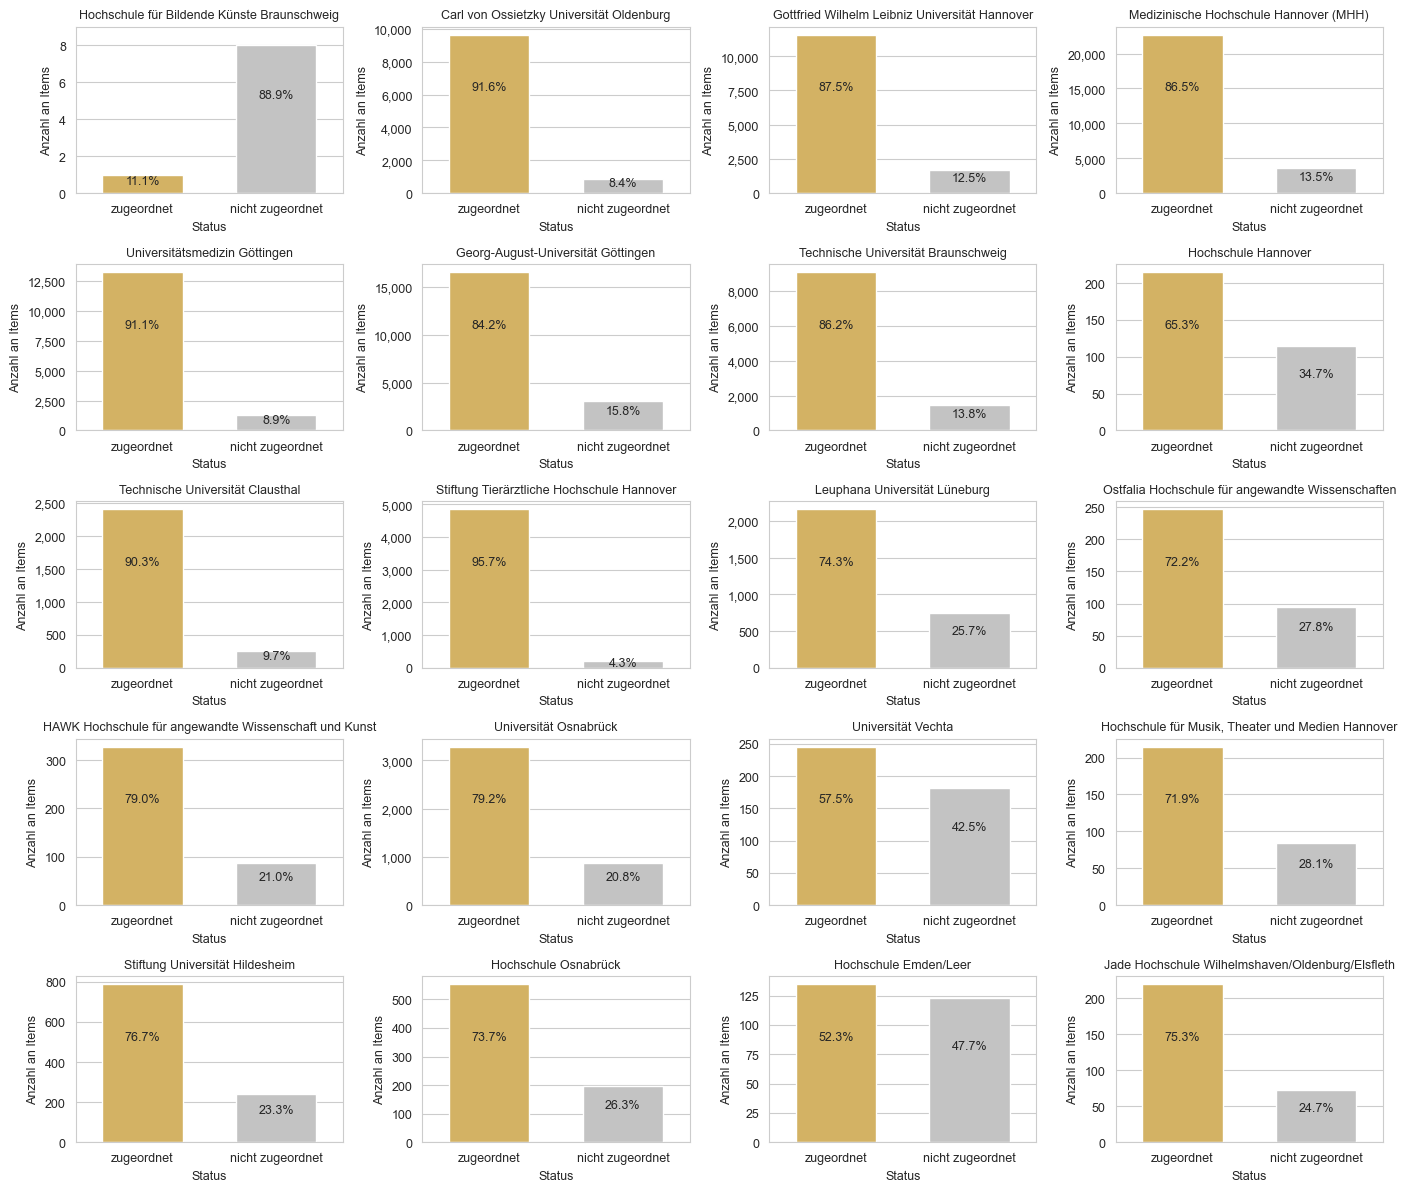

In [81]:
fig, axes = plt.subplots(nrows=5, 
                         ncols=4, 
                         sharex=False, 
                         sharey=False, 
                         figsize=(14,12))

axes = axes.reshape(-1)

for i, ax in enumerate(axes, 0):

    parent_name = liste_aller_hochschulen[i-1]

    df_temp = map_df[map_df.parent_name == parent_name].copy()
    df_temp.fillna('Nicht zugeordnet', inplace=True)

    number_of_items_mapped = df_temp[df_temp.fak_name != 'Nicht zugeordnet'].doi.count()
    number_of_items_not_mapped = df_temp[df_temp.fak_name == 'Nicht zugeordnet'].doi.count()

    prop = df_temp[df_temp.fak_name != 'Nicht zugeordnet'].doi.count() / df_temp.doi.count()

    data = {
        'mapped_indicator': ['zugeordnet', 'nicht zugeordnet'],
        'n': [number_of_items_mapped, number_of_items_not_mapped],
        'prop': [format(prop, '.1%'), format(1-prop, '.1%')]
    }
    
    df = pd.DataFrame(data)
    
    sns.barplot(data=df, 
                x='mapped_indicator', 
                y='n', 
                width=0.6,
                hue='mapped_indicator',
                palette=['#E5BA52', '#c3c3c3'],
                ax=ax).set_title(parent_name, fontdict=dict(fontsize=9, fontweight=500))

    for idx, row in df.iterrows():
        ax.text(row['mapped_indicator'], 
                row['n'] / 1.5, 
                row['prop'], 
                verticalalignment='center', 
                horizontalalignment='center', 
                fontdict=dict(fontsize=9, fontweight=500))

    if parent_name == 'Hochschule für Bildende Künste Braunschweig':
        ax.set_ylim(0, 9)
        ax.set_yticks(range(0, 9, 2))

    ax.set(xlabel='Status', ylabel='Anzahl an Items')

    ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()

plt.show()
fig.savefig('mapping.png', format='png', bbox_inches='tight', dpi=600)

In [36]:
map_df.sample(10)

,parent_name,fak_name,raw_affiliation_string,doi
80819,Georg-August-Universität Göttingen,Fakultät für Geowissenschaften und Geographie,"Department of Physical Geography, Institute of...",10.1002/esp.5116
57985,Georg-August-Universität Göttingen,Fakultät für Forstwissenschaften und Waldökologie,"Wildlife Sciences, University of Goettingen, B...",10.1007/s10592-020-01248-8
64966,Medizinische Hochschule Hannover (MHH),None,"REBIRTH Cluster of Excellence, Hannover Medica...",10.1089/cell.2019.0107
3293,Carl von Ossietzky Universität Oldenburg,ForWind - Zentrum für Windenergieforschung,"ForWind - Center for Wind Energy Research, Uni...",10.1371/journal.pone.0252790
106536,Georg-August-Universität Göttingen,Fakultät für Biologie und Psychologie,"Georg-Elias-Müller-Institut für Psychologie, U...",10.3389/fpsyg.2021.718141
184,Carl von Ossietzky Universität Oldenburg,Helmholtz-Institut für Funktionelle Marine Bio...,Helmholtz Inst. for Functional Marine Biodiver...,10.1111/ecog.05869
27897,Georg-August-Universität Göttingen,Fakultät für Agrarwissenschaften,Department of Animal Science Georg‐August‐Univ...,10.1002/jmor.21675
18474,Medizinische Hochschule Hannover (MHH),None,"Department of Medicine II, Saarland University...",10.1053/j.gastro.2021.03.049
86303,Carl von Ossietzky Universität Oldenburg,Fakultät VI - Medizin und Gesundheitswissensch...,"Big Data in Medicine, Department of Health Ser...",10.1055/s-0042-1760238
70599,Gottfried Wilhelm Leibniz Universität Hannover,Fakultät für Mathematik und Physik,"Institute of Quantum Optics, Leibniz Universit...",10.1038/s41598-020-65950-w


## GERiT Level 2

In [37]:
with open('institution_mapping/mapping_tables_dept/clausthal.json', 'r') as file:
    CLAUSTHAL_DEPT_MAPPING = json.load(file)

In [38]:
with open('institution_mapping/mapping_tables_dept/emden.json', 'r') as file:
    EMDEN_DEPT_MAPPING = json.load(file)

In [39]:
with open('institution_mapping/mapping_tables_dept/gau.json', 'r') as file:
    GAU_DEPT_MAPPING = json.load(file)

In [40]:
with open('institution_mapping/mapping_tables_dept/hawk.json', 'r') as file:
    HAWK_DEPT_MAPPING = json.load(file)

In [41]:
#with open('institution_mapping/mapping_tables_dept/hbk.json', 'r') as file:
#    HBK_DEPT_MAPPING = json.load(file)

In [42]:
with open('institution_mapping/mapping_tables_dept/hildesheim.json', 'r') as file:
    HILDESHEIM_DEPT_MAPPING = json.load(file)

In [43]:
#with open('institution_mapping/mapping_tables_dept/hmtmh.json', 'r') as file:
#    HMTMH_DEPT_MAPPING = json.load(file)

In [44]:
with open('institution_mapping/mapping_tables_dept/hsh.json', 'r') as file:
    HSH_DEPT_MAPPING = json.load(file)

In [45]:
with open('institution_mapping/mapping_tables_dept/hsosnabrueck.json', 'r') as file:
    HSOSNABRÜCK_DEPT_MAPPING = json.load(file)

In [46]:
with open('institution_mapping/mapping_tables_dept/jade.json', 'r') as file:
    JADE_DEPT_MAPPING = json.load(file)

In [47]:
with open('institution_mapping/mapping_tables_dept/leibniz.json', 'r') as file:
    LEIBNIZ_DEPT_MAPPING = json.load(file)

In [48]:
with open('institution_mapping/mapping_tables_dept/leuphana.json', 'r') as file:
    LEUPHANA_DEPT_MAPPING = json.load(file)

In [49]:
with open('institution_mapping/mapping_tables_dept/mhh.json', 'r') as file:
    MHH_DEPT_MAPPING = json.load(file)

In [50]:
with open('institution_mapping/mapping_tables_dept/oldenburg.json', 'r') as file:
    OLDENBURG_DEPT_MAPPING = json.load(file)

In [51]:
with open('institution_mapping/mapping_tables_dept/ostfalia.json', 'r') as file:
    OSTFALIA_DEPT_MAPPING = json.load(file)

In [52]:
#with open('institution_mapping/mapping_tables_dept/tiho.json', 'r') as file:
#    TIHO_DEPT_MAPPING = json.load(file)

In [53]:
with open('institution_mapping/mapping_tables_dept/tubraunschweig.json', 'r') as file:
    TUBRAUNSCHWEIG_DEPT_MAPPING = json.load(file)

In [54]:
with open('institution_mapping/mapping_tables_dept/uosnabrueck.json', 'r') as file:
    UOSNABRÜCK_DEPT_MAPPING = json.load(file)

In [55]:
with open('institution_mapping/mapping_tables_dept/vechta.json', 'r') as file:
    VECHTA_DEPT_MAPPING = json.load(file)

In [56]:
MAPPING_DICT_DEPT = {
    'Technische Universität Clausthal': CLAUSTHAL_DEPT_MAPPING,
    'Hochschule Emden/Leer': EMDEN_DEPT_MAPPING,
    'Georg-August-Universität Göttingen': GAU_DEPT_MAPPING,
    'HAWK Hochschule für angewandte Wissenschaft und Kunst': HAWK_DEPT_MAPPING,
    #'Hochschule für Bildende Künste Braunschweig': HBK_DEPT_MAPPING,
    'Stiftung Universität Hildesheim': HILDESHEIM_DEPT_MAPPING,
    #'Hochschule für Musik, Theater und Medien Hannover': HMTMH_DEPT_MAPPING,
    'Hochschule Hannover': HSH_DEPT_MAPPING,
    'Hochschule Osnabrück': HSOSNABRÜCK_DEPT_MAPPING,
    'Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth': JADE_DEPT_MAPPING,
    'Gottfried Wilhelm Leibniz Universität Hannover': LEIBNIZ_DEPT_MAPPING,
    'Leuphana Universität Lüneburg': LEUPHANA_DEPT_MAPPING,
    'Medizinische Hochschule Hannover (MHH)': MHH_DEPT_MAPPING,
    'Carl von Ossietzky Universität Oldenburg': OLDENBURG_DEPT_MAPPING,
    'Ostfalia Hochschule für angewandte Wissenschaften': OSTFALIA_DEPT_MAPPING,
    #'Stiftung Tierärztliche Hochschule Hannover': TIHO_DEPT_MAPPING,
    'Technische Universität Braunschweig': TUBRAUNSCHWEIG_DEPT_MAPPING,
    'Universität Osnabrück': UOSNABRÜCK_DEPT_MAPPING,
    'Universität Vechta': VECHTA_DEPT_MAPPING
}

In [57]:
def map_dept(row: pd.Series, mapping_dict: dict) -> Union[str, None]:

    address = row['raw_affiliation_string']
    faculty = row['fak_name']
    
    
    if faculty in mapping_dict:
        for k, v in mapping_dict.get(faculty).items():
            pattern = re.compile(r'|'.join(v), re.IGNORECASE)
            res = bool(pattern.search(address))
            if res:
                return k
        return None
    else:
        return None

In [58]:
for k, v in MAPPING_DICT_DEPT.items():
    map_df.loc[map_df['parent_name'] == k, 'dept_name'] = \
        map_df.loc[map_df['parent_name'] == k].apply(map_dept, axis=1, mapping_dict=v)

In [59]:
map_df.head(5)

,parent_name,fak_name,raw_affiliation_string,doi,dept_name
0,Carl von Ossietzky Universität Oldenburg,Helmholtz-Institut für Funktionelle Marine Bio...,4Helmholtz Institute for Functional Marine Bio...,10.1525/elementa.2021.00117,None
1,Carl von Ossietzky Universität Oldenburg,Helmholtz-Institut für Funktionelle Marine Bio...,Helmholtz Institute for Functional Marine Biod...,10.1038/s41598-022-17999-y,None
2,Carl von Ossietzky Universität Oldenburg,Helmholtz-Institut für Funktionelle Marine Bio...,Helmholtz Institute for Functional Marine Biod...,10.3389/fmars.2023.1159762,None
3,Carl von Ossietzky Universität Oldenburg,Helmholtz-Institut für Funktionelle Marine Bio...,Helmholtz Institute for Functional Marine Biod...,10.3389/fmars.2023.1128322,None
4,Carl von Ossietzky Universität Oldenburg,Helmholtz-Institut für Funktionelle Marine Bio...,Helmholtz Institute for Functional Marine Biod...,10.5194/esd-13-1677-2022,None


## Verknüpfung mit GERiT ID

In [60]:
map_df_with_gerit = map_df.copy()

In [61]:
map_df_with_gerit.loc[map_df_with_gerit['parent_name'] == 'Universitätsmedizin Göttingen', 'parent_name'] = 'Georg-August-Universität Göttingen'

In [62]:
gerit_ids = pd.read_csv('gerit_inst_with_ids.csv')

In [63]:
gerit_ids.head()

,dfg_id,inst_name,level,parent_name,dfg_id_parent
0,14332,Bibliotheks- und Informationssystem (BIS),level0,Carl von Ossietzky Universität Oldenburg,10233
1,14349,Center für lebenslanges Lernen (C3L),level0,Carl von Ossietzky Universität Oldenburg,10233
2,19052,"CMC - Center for Migration, Education and Cult...",level0,Carl von Ossietzky Universität Oldenburg,10233
3,35245680,COAST - Zentrum für Umwelt- und Nachhaltigkeit...,level0,Carl von Ossietzky Universität Oldenburg,10233
4,25628,ecco-ecology + communication Unternehmensberat...,level0,Carl von Ossietzky Universität Oldenburg,10233


In [64]:
gerit_ids[gerit_ids.dfg_id == 13002060]

,dfg_id,inst_name,level,parent_name,dfg_id_parent
1226,13002060,Abteilung Experimentelle Neurodegeneration,level1,Georg-August-Universität Göttingen,10236


In [65]:
map_df_with_gerit = map_df_with_gerit.merge(gerit_ids[['parent_name', 'inst_name', 'dfg_id', 'dfg_id_parent']], 
                                            left_on=['parent_name', 'fak_name'], 
                                            right_on=['parent_name', 'inst_name'], 
                                            how='left')

In [66]:
map_df_with_gerit.drop(['inst_name'], axis=1, inplace=True)
map_df_with_gerit.rename(columns={'dfg_id': 'dfg_id_fak'}, inplace=True)

In [67]:
map_df_with_gerit['dfg_id_fak']= map_df_with_gerit['dfg_id_fak'].astype('Int64')
map_df_with_gerit['dfg_id_parent']= map_df_with_gerit['dfg_id_parent'].astype('Int64')

In [68]:
map_df_with_gerit = map_df_with_gerit.merge(gerit_ids[['parent_name', 'inst_name', 'dfg_id']], 
                                            left_on=['parent_name', 'dept_name'], 
                                            right_on=['parent_name', 'inst_name'], 
                                            suffixes=(None, '_dept'),
                                            how='left')

In [69]:
map_df_with_gerit.drop(['inst_name'], axis=1, inplace=True)
map_df_with_gerit.rename(columns={'dfg_id': 'dfg_id_dept'}, inplace=True)

In [70]:
map_df_with_gerit['dfg_id_fak']= map_df_with_gerit['dfg_id_fak'].astype('Int64')
map_df_with_gerit['dfg_id_dept']= map_df_with_gerit['dfg_id_dept'].astype('Int64')
map_df_with_gerit['dfg_id_parent']= map_df_with_gerit['dfg_id_parent'].astype('Int64')

In [71]:
umg_all_inst = list(map_df[map_df.parent_name == 'Universitätsmedizin Göttingen'].fak_name.unique())
umg_all_inst.remove(None)

In [72]:
map_df_with_gerit.loc[(map_df_with_gerit['parent_name'] == 'Georg-August-Universität Göttingen') \
    & (map_df_with_gerit['fak_name'].isin(umg_all_inst)),
    'parent_name'] = 'Universitätsmedizin Göttingen'

In [73]:
map_df_with_gerit.sample(5)

,parent_name,fak_name,raw_affiliation_string,doi,dept_name,dfg_id_fak,dfg_id_parent,dfg_id_dept
28096,Medizinische Hochschule Hannover (MHH),Zentrum Laboratoriumsmedizin,"Institute of Clinical Chemistry, Hannover Medi...",10.3390/jcm10050971,Institut für Klinische Chemie,13803,10247,17207
16148,Medizinische Hochschule Hannover (MHH),Zentrum Innere Medizin,"Department for Rheumatology and Immunology, Ha...",10.1136/annrheumdis-2021-220435,Klinik für Rheumatologie und Immunologie,981469,10247,29467
58315,Medizinische Hochschule Hannover (MHH),Zentrum für Radiologie,Department of Diagnostic and Interventional Ne...,10.1177/15910199221121398,Institut für Diagnostische und Interventionell...,13809,10247,17222
88724,Technische Universität Braunschweig,"Fakultät für Elektrotechnik, Informationstechn...","Institut fÃ¼r Theoretische Physik, Technische ...",10.5194/angeo-39-165-2021,Abteilung für Physik,13368,10240,13363
81256,Gottfried Wilhelm Leibniz Universität Hannover,Fakultät für Mathematik und Physik,"Institute of Meteorology and Climatology, Leib...",10.1007/s10546-024-00868-8,Institut für Meteorologie und Klimatologie,28560,10238,17333


## Erstellung von Samples

In [74]:
for hochschule in liste_aller_hochschulen:

    sample_size = 100

    df_hochschule = map_df[map_df.parent_name == hochschule].copy()

    if len(df_hochschule) < 100:
        sample_size = len(df_hochschule)

    df_sample = df_hochschule.sample(sample_size, random_state=42)

    filename = hochschule

    if hochschule == 'Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth':
        filename = 'Jade Hochschule Wilhelmshaven Oldenburg Elsfleth'

    if hochschule == 'Hochschule Emden/Leer':
        filename = 'Hochschule Emden Leer'

    df_sample[['doi', 'parent_name', 'raw_affiliation_string', 'fak_name', 'dept_name']].to_csv(f'samples/{filename}_sample.csv', index=False)